In [776]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os
import pyshark

Versions for libraries imported 

In [777]:
print(np.__version__)
print(matplotlib.__version__)
print(pd.__version__)


1.26.4
3.10.6
2.3.3


Some constants definitions

In [778]:


Experiment1Folder="VehicleExperiment_Output"
Experiment2Folder="SpeedExperiment_Output"
Experiment3Folder="PERExperiment_Output"


QUICDataFolder="QUIC"
TCPDataFolder="TCP"
CombinedDataOutputFolder='CombinedData'
QUICCSVFiles=[]
TCPCSVFiles=[]
NumOfTrials=50
NumOfIndexs=7
NumOfPERValues=6
NumOfVehicles=6
NumOfSpeedValues=7
#Constants
VEHICLEINDEX=0
SPEEDINDEX=1
PERINDEX=2
AVGDELAYINDEX=3
P95INDEX=4
JITTERINDEX=5
GOODPUTINDEX=6

Make output folder

In [779]:
try:
    os.mkdir(CombinedDataOutputFolder)
except:
    print("error making folder")

error making folder


In [780]:
#List directorys for data.
def GetCSVFiles(QUICPath,TCPPath):
    try:
        QUICCSVFiles=os.listdir(QUICPath)
        TCPCSVFiles=os.listdir(TCPPath)

        return QUICCSVFiles,TCPCSVFiles
    except:
        print("couldn't open folder")
        return 0,0

In [781]:
#Print std of both arrays
def PrintStatistics(TCPArr,QUICArr):
    print(np.shape(QUICArr))
    print("QUIC stats")
    print(np.std(QUICArr,axis=(0)))
    print("TCP stats")
    print(np.std(TCPArr,axis=(0)))

Code for sorting out the dataset and for getting it ready to be plotted.

In [782]:
def GetDataArrays(ROWS,QUICPath,TCPPath):
    #Load files in
    QUICCSVFiles, TCPCSVFiles=GetCSVFiles(QUICPath,TCPPath)
    #Allocate array space.
    QUICarray=np.zeros(shape=(NumOfTrials,ROWS,NumOfIndexs))
    TCParray=np.zeros(shape=(NumOfTrials,ROWS,NumOfIndexs))
    #For getting rid of bad data due to the simulation crashing.
    BadFiles=[]
    #get data
    for i in range(0,NumOfTrials):
        Temp=np.loadtxt(QUICPath+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        Temp2=np.loadtxt(TCPPath+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        if (np.shape(Temp)[0]==ROWS and np.shape(Temp2)[0]==ROWS):
            QUICarray[i]=np.loadtxt(QUICPath+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
            TCParray[i]=np.loadtxt(TCPPath+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        else:
            BadFiles.append(i)
    #temp arrays
    temp=np.zeros(shape=(NumOfTrials-len(BadFiles),ROWS,NumOfIndexs))
    temp2=np.zeros(shape=(NumOfTrials-len(BadFiles),ROWS,NumOfIndexs))
    print(len(BadFiles))
    index=0
    badfileindex=0
    #Remove bad files here and redefine the QUIC and TCP arrays.
    if (len(BadFiles)!=0):
     for i in range(0,NumOfTrials):
        if (i==BadFiles[badfileindex]):
            #index=index+1
            badfileindex=badfileindex+1
            if (badfileindex>=len(BadFiles)):
                badfileindex=0
        else:
            temp[index]=QUICarray[i]
            temp2[index]=TCParray[i]
            index=index+1
     QUICarray=temp
     TCParray=temp2
    PrintStatistics(TCParray[0:,0:,AVGDELAYINDEX],QUICarray[0:,0:,AVGDELAYINDEX])
    return QUICarray,TCParray

This one returns average and median results of each category

In [783]:
def GetAverageandMedianArrays(ROWS,QUICPath,TCPPath):

    QUICarray,TCParray = GetDataArrays(ROWS,QUICPath,TCPPath)
    
    AverageQUICResults=np.zeros(shape=(ROWS,NumOfIndexs))
    AverageTCPResults=np.zeros(shape=(ROWS,NumOfIndexs))
    MedianQUICResults=np.zeros(shape=(ROWS,NumOfIndexs))
    MedianTCPResults=np.zeros(shape=(ROWS,NumOfIndexs))
    for i in range(0,NumOfIndexs):
        for j in range(0,ROWS):
            AverageQUICResults[j,i]=np.average(QUICarray[0:,j,i])
            AverageTCPResults[j,i]=np.average(TCParray[0:,j,i])
            MedianQUICResults[j,i]=np.median(QUICarray[0:,j,i])
            MedianTCPResults[j,i]=np.median(TCParray[0:,j,i])
    return AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults

Graph plotting code

In [784]:
def PlotQUICVsTCP(QUICArray,TCPArray,Title,XLabel,YLabel):
    plt.plot(QUICArray[0:,0],QUICArray[0:,1],label="QUIC")
    plt.plot(TCPArray[0:,0],TCPArray[0:,1],label="TCP")
    plt.legend()
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()
def PlotBoxplot(Arr,Title,XLabel,YLabel,ticklabels):
    plt.boxplot(Arr,tick_labels=ticklabels)
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()

Load data for experiment 3.  

In [785]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfPERValues,Experiment3Folder+"/"+QUICDataFolder, Experiment3Folder+"/"+TCPDataFolder)
QUICResults,TCPResults=GetDataArrays(NumOfPERValues,Experiment3Folder+"/"+QUICDataFolder, Experiment3Folder+"/"+TCPDataFolder)

4
(46, 6)
QUIC stats
[ 1.83549018  8.46786009 27.06593761 55.31677895 54.8410349  46.65584461]
TCP stats
[ 8.93666932 10.02207798 12.40138334 28.44985478 31.6342398  18.42434982]
4
(46, 6)
QUIC stats
[ 1.83549018  8.46786009 27.06593761 55.31677895 54.8410349  46.65584461]
TCP stats
[ 8.93666932 10.02207798 12.40138334 28.44985478 31.6342398  18.42434982]


Save Experiment data into a combined .csv file.  It is easier to work with in this way.

In [786]:
CombinedFileName="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,AverageTCPResults,delimiter=',')


Average Results

Average results
[  8.75168587  12.34461935  26.41803239 163.46869565 252.5710413
 134.67168261]
[ 35.87707609  41.14114783  54.63695    207.08832609 234.25506522
  66.64599348]


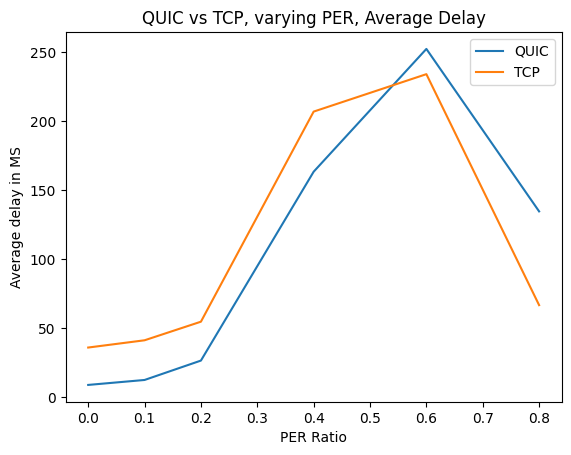

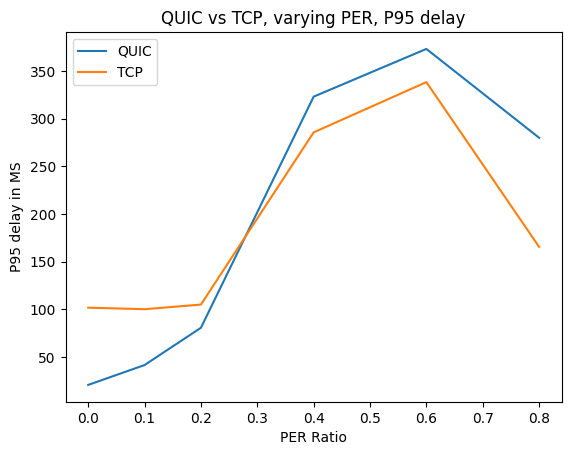

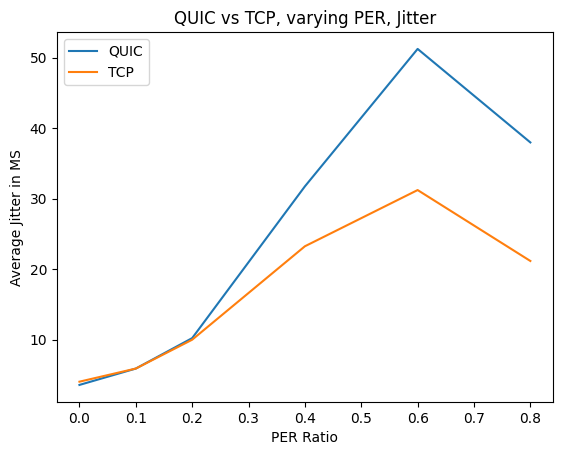

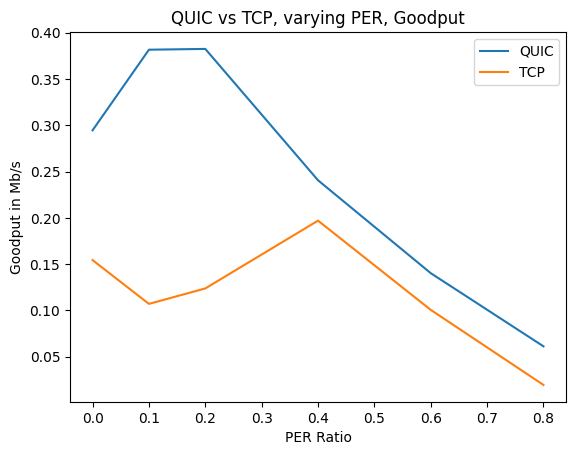

In [787]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))

print(AvgDelayArrayQUIC[0:,1])
print(AvgDelayArrayTCP[0:,1])



PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying PER, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying PER, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying PER, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying PER, Goodput","PER Ratio","Goodput in Mb/s")





In [788]:
print("Averages, QUIC VS TCP")
print(AvgDelayArrayQUIC[0:,1])
print(AvgDelayArrayTCP[0:,1])
print("P95, QUIC VS TCP")
print("QUIC: ",P95ArrayQUIC[0:,1])
print("TCP: ",P95ArrayTCP[0:,1])
print("MAX, QUIC VS TCP")
print(np.max(GoodputArrayQUIC[0:,1]))
print(np.max(GoodputArrayTCP[0:,1]))
print("MIN, QUIC VS TCP")

print(np.min(GoodputArrayQUIC[0:,1]))
print(np.min(GoodputArrayTCP[0:,1]))

Averages, QUIC VS TCP
[  8.75168587  12.34461935  26.41803239 163.46869565 252.5710413
 134.67168261]
[ 35.87707609  41.14114783  54.63695    207.08832609 234.25506522
  66.64599348]
P95, QUIC VS TCP
QUIC:  [ 20.4540913   41.34047261  80.49350217 323.24902174 373.38613043
 280.06417391]
TCP:  [101.60426522  99.98561957 104.8527     285.7385     338.50828261
 165.47757391]
MAX, QUIC VS TCP
0.38238150000000004
0.19694495652173916
MIN, QUIC VS TCP
0.06121819239130435
0.01955642391304348


In [789]:
CombinedFileName="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,MedianTCPResults,delimiter=',')

Median results

Median results


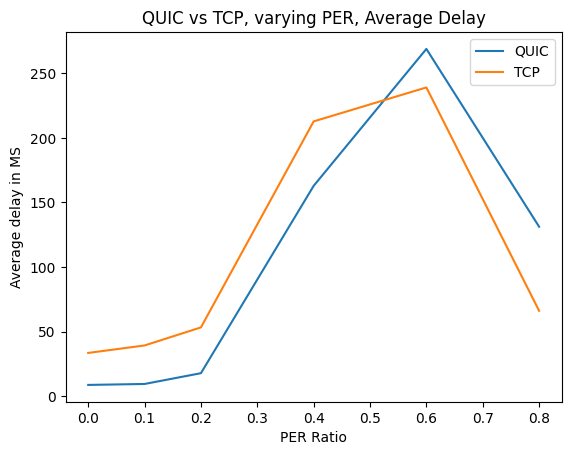

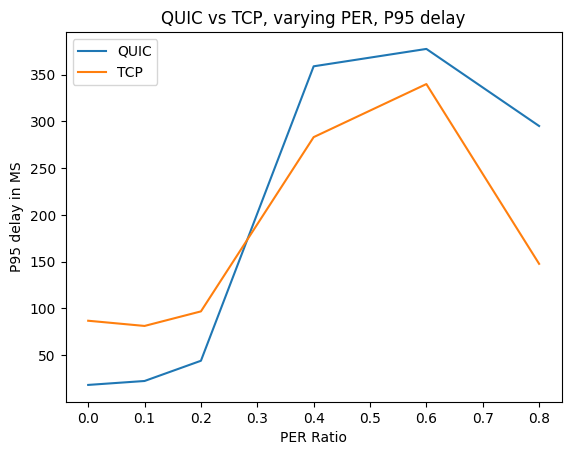

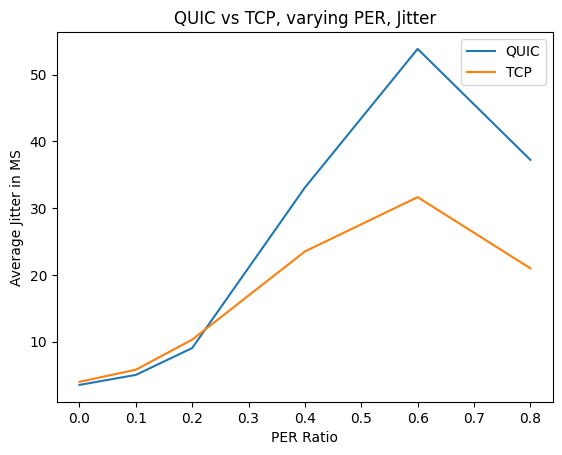

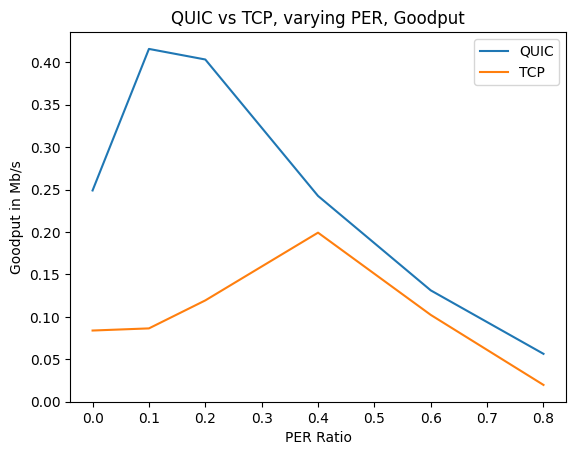

In [790]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying PER, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying PER, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying PER, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying PER, Goodput","PER Ratio","Goodput in Mb/s")


Boxplot

Boxplot


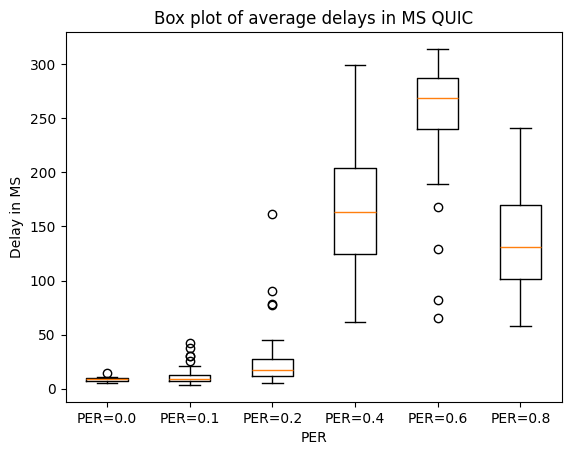

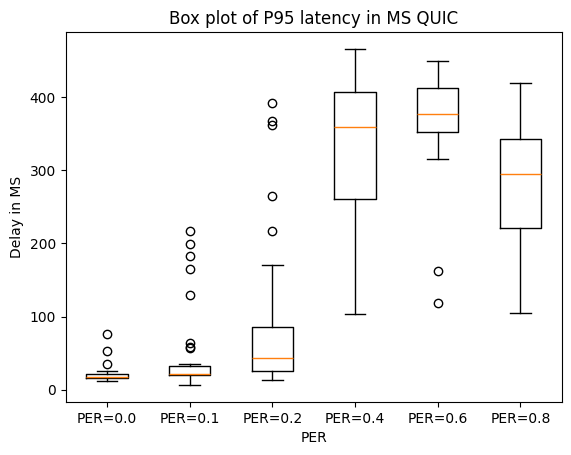

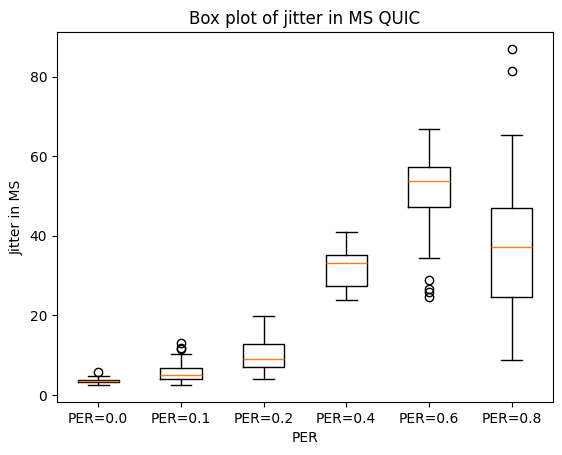

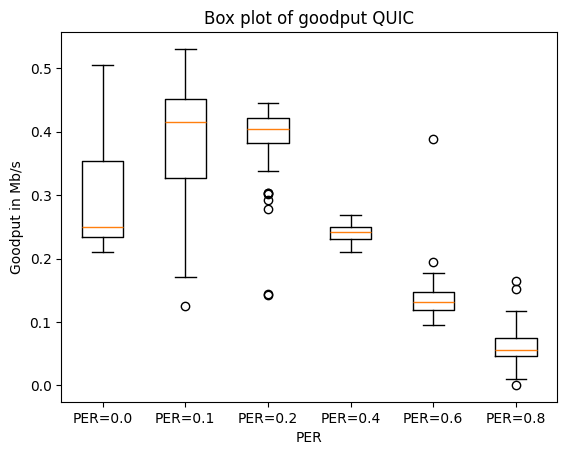

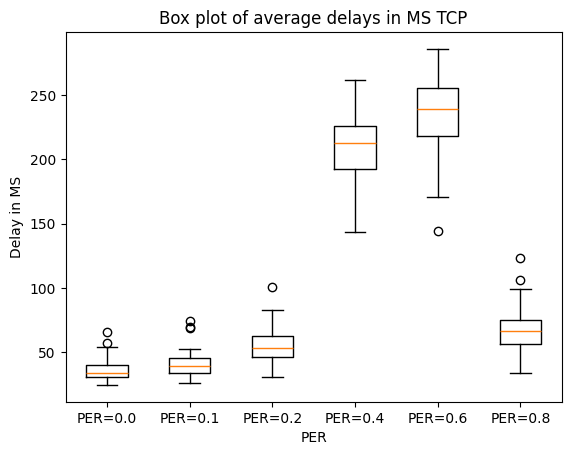

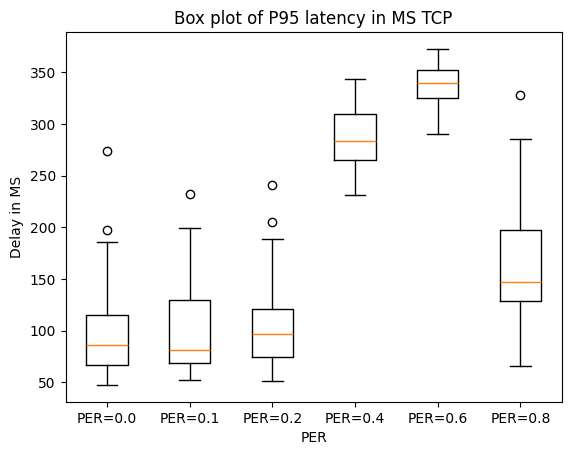

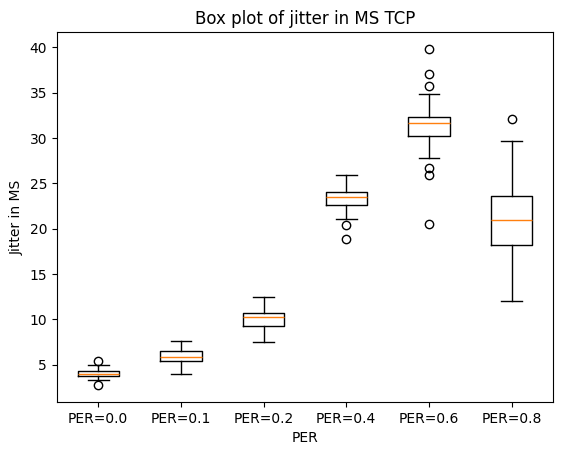

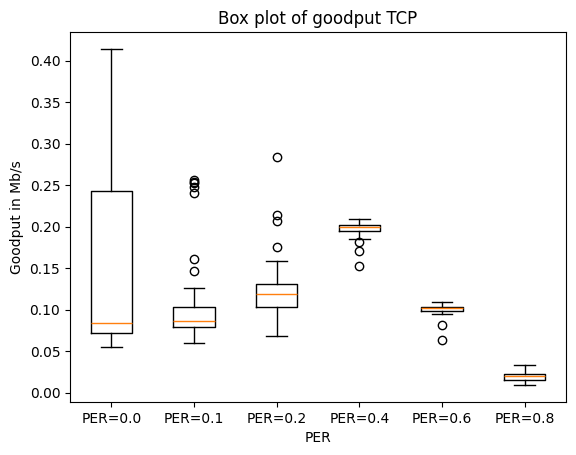

In [791]:
#BoxPlot
QUICCategories = QUICResults[0:,0:,3:7]
TCPCategories = TCPResults[0:,0:,3:7]
MetricStringsYLabel = ["Delay in MS", "Delay in MS", "Jitter in MS", "Goodput in Mb/s"]
MetricStringsTitles = ["Box plot of average delays in MS ", "Box plot of P95 latency in MS ", "Box plot of jitter in MS ", "Box plot of goodput "]
ticklabelsPER=["PER=0.0","PER=0.1","PER=0.2","PER=0.4","PER=0.6","PER=0.8"]
print("Boxplot")
####Box plots has a IQR value of 1.5 this is very popular according to wikipedia
#Plot QUIC
for i in range(0,len(MetricStringsYLabel)):
    PlotBoxplot(QUICCategories[0:,0:,i],MetricStringsTitles[i]+"QUIC","PER",MetricStringsYLabel[i],ticklabelsPER)
#Plot TCP
for i in range(0,len(MetricStringsYLabel)):
    PlotBoxplot(TCPCategories[0:,0:,i],MetricStringsTitles[i]+"TCP","PER",MetricStringsYLabel[i],ticklabelsPER)

In [792]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfVehicles,Experiment1Folder+"/"+QUICDataFolder, Experiment1Folder+"/"+TCPDataFolder)
QUICResults,TCPResults=GetDataArrays(NumOfVehicles,Experiment1Folder+"/"+QUICDataFolder, Experiment1Folder+"/"+TCPDataFolder)


2
(48, 6)
QUIC stats
[ 0.99116571  2.12040086  2.65975808 24.81211747 47.75946049 29.54397409]
TCP stats
[4.58806148e-03 6.41889372e+00 9.27662694e+00 8.64793906e+00
 8.69303956e+00 1.28181891e+01]
2
(48, 6)
QUIC stats
[ 0.99116571  2.12040086  2.65975808 24.81211747 47.75946049 29.54397409]
TCP stats
[4.58806148e-03 6.41889372e+00 9.27662694e+00 8.64793906e+00
 8.69303956e+00 1.28181891e+01]


In [793]:
CombinedFileNameMedian="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,MedianTCPResults,delimiter=',')

CombinedFileNameAverage="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,AverageTCPResults,delimiter=',')


Average results

Average results


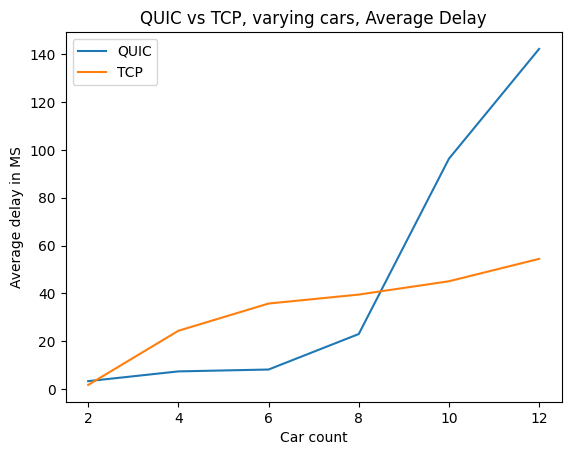

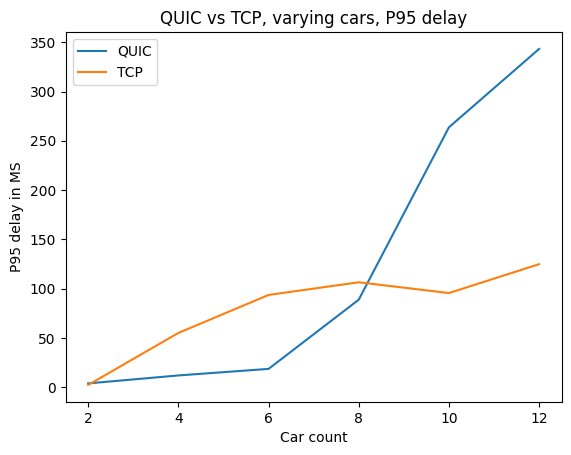

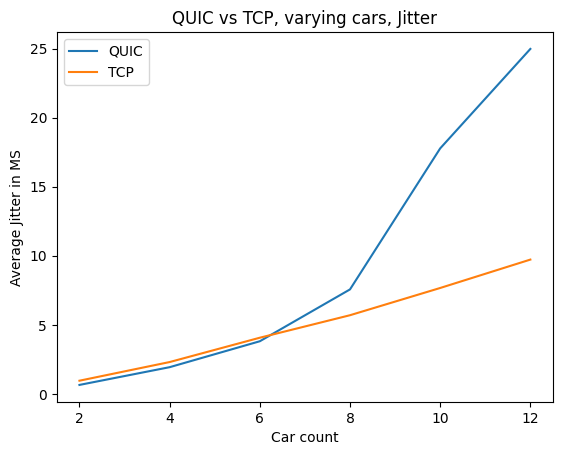

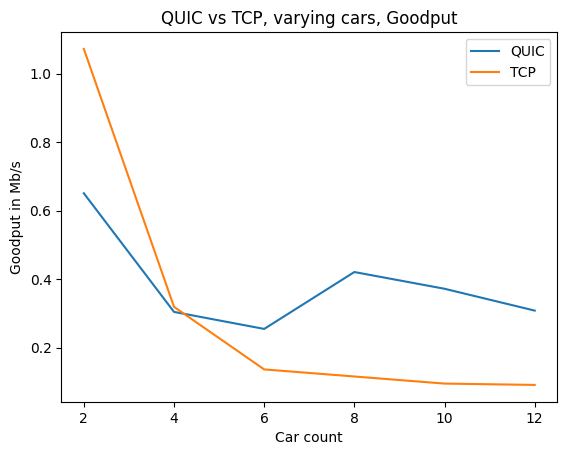

In [794]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying cars, Average Delay","Car count","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying cars, P95 delay","Car count","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying cars, Jitter","Car count","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying cars, Goodput","Car count","Goodput in Mb/s")

Print out contents of the arrays


In [795]:
print("Averages, QUIC VS TCP")
print(AvgDelayArrayQUIC[0:,1])
print(AvgDelayArrayTCP[0:,1])
print("P95, QUIC VS TCP")
print("QUIC: ",P95ArrayQUIC[0:,1])
print("TCP: ",P95ArrayTCP[0:,1])

print("MAX, QUIC VS TCP")
print(np.max(GoodputArrayQUIC[0:,1]))
print(np.max(GoodputArrayTCP[0:,1]))
print("MIN, QUIC VS TCP")
print(np.min(GoodputArrayQUIC[0:,1]))
print(np.min(GoodputArrayTCP[0:,1]))

Averages, QUIC VS TCP
[  3.30864563   7.37771896   8.16227562  22.99900771  96.27999583
 142.19286667]
[ 1.72334208 24.36356063 35.74225625 39.4944     45.05766458 54.41961458]
P95, QUIC VS TCP
QUIC:  [  3.79788792  11.86817438  18.51707104  88.74337562 263.67581458
 343.21375   ]
TCP:  [  2.25163833  55.0144125   93.55016667 106.4217      95.47135208
 124.77621458]
MAX, QUIC VS TCP
0.6509463958333332
1.0723551041666668
MIN, QUIC VS TCP
0.25489193895833334
0.09140226041666666


Median results

Median results


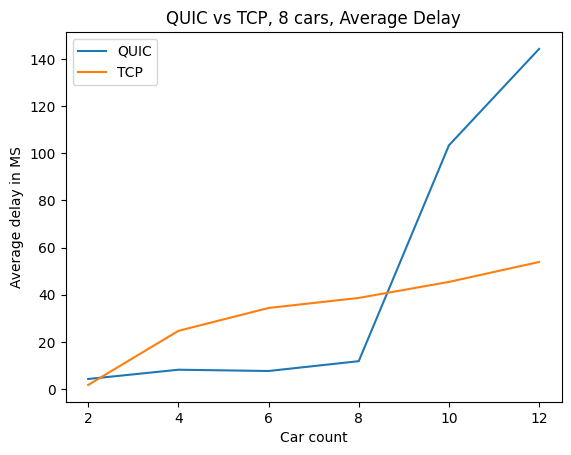

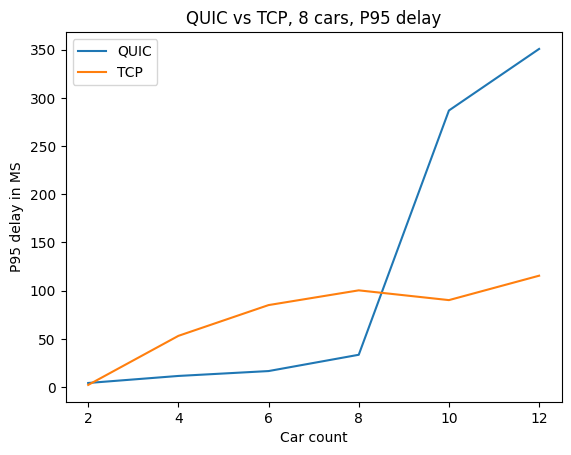

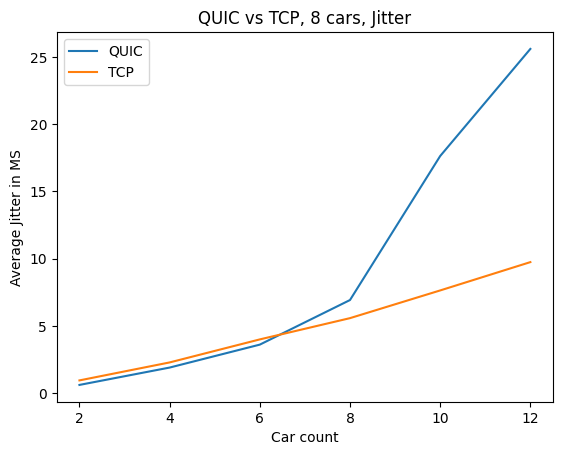

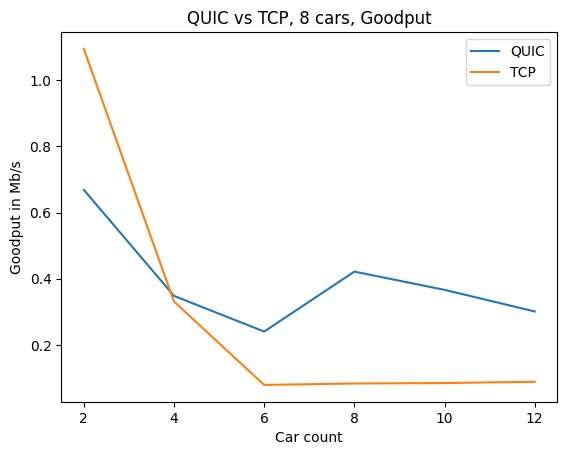

In [796]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","Car count","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","Car count","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","Car count","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","Car count","Goodput in Mb/s")


Boxplots

Boxplot


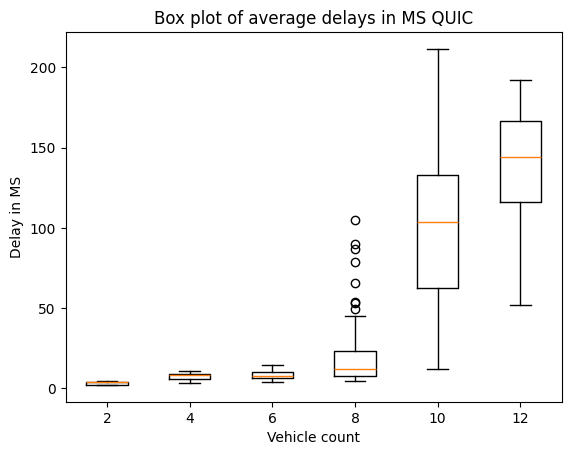

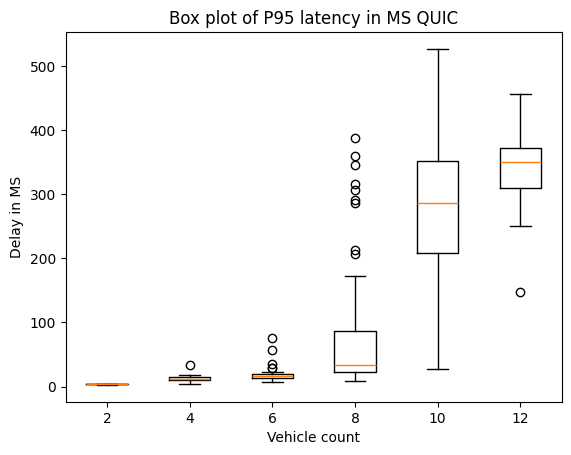

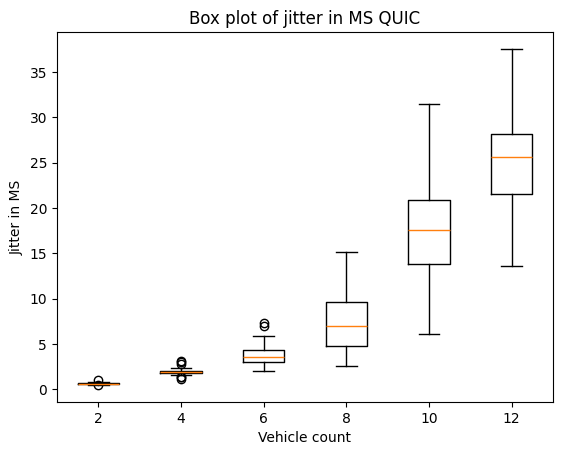

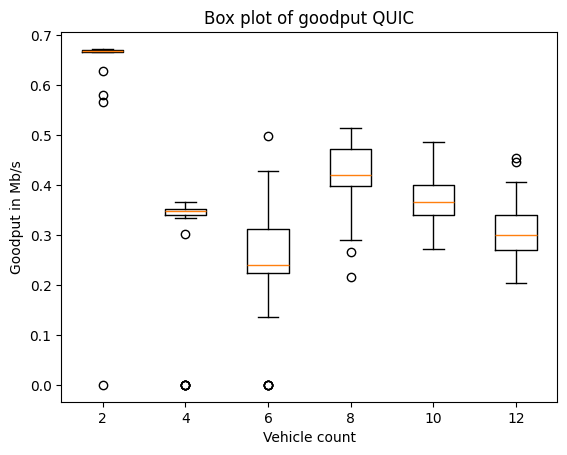

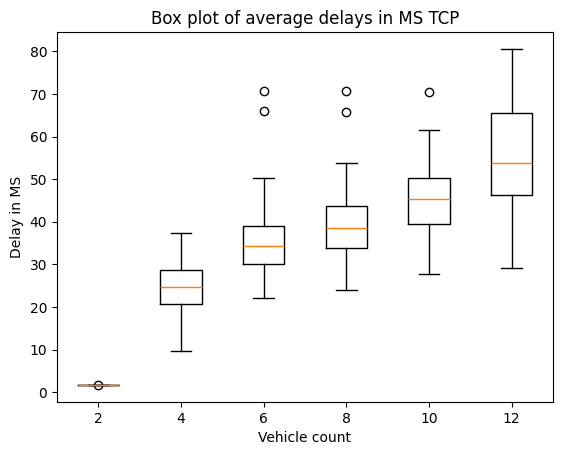

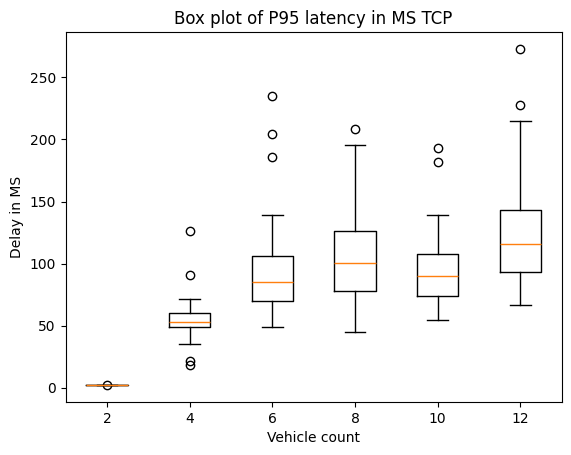

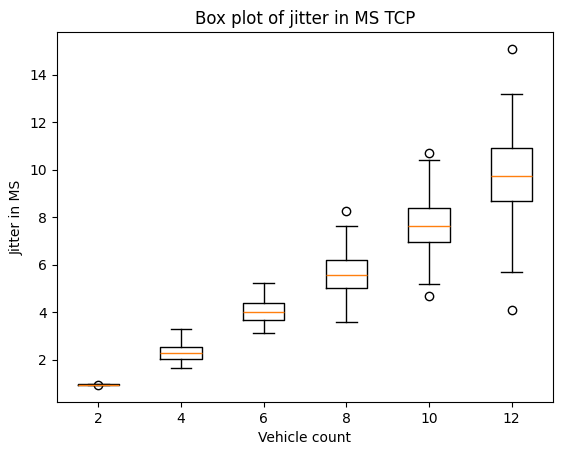

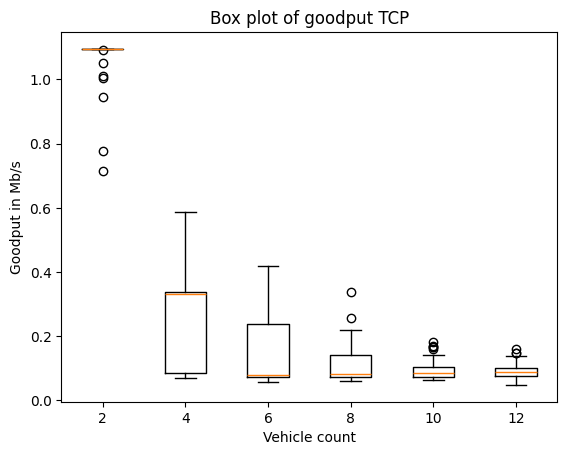

In [797]:
#BoxPlot
QUICCategories = QUICResults[0:,0:,3:7]
TCPCategories = TCPResults[0:,0:,3:7]
ticklabelsVehicleCount=["2","4","6","8","10","12"]
print("Boxplot")
####Box plots has a IQR value of 1.5 this is very popular according to wikipedia
#Plot QUIC
for i in range(0,len(MetricStringsYLabel)):
    PlotBoxplot(QUICCategories[0:,0:,i],MetricStringsTitles[i]+"QUIC","Vehicle count",MetricStringsYLabel[i],ticklabelsVehicleCount)
#Plot TCP
for i in range(0,len(MetricStringsYLabel)):
    PlotBoxplot(TCPCategories[0:,0:,i],MetricStringsTitles[i]+"TCP","Vehicle count",MetricStringsYLabel[i],ticklabelsVehicleCount)

Experiment 2 Speed test

In [798]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfSpeedValues,Experiment2Folder+"/"+QUICDataFolder, Experiment2Folder+"/"+TCPDataFolder)
QUICResults,TCPResults=GetDataArrays(NumOfSpeedValues,Experiment2Folder+"/"+QUICDataFolder, Experiment2Folder+"/"+TCPDataFolder)

CombinedFileNameMedian="CombinedMedianExperiment2.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,MedianTCPResults,delimiter=',')

CombinedFileNameAverage="CombinedAverageExperiment2.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,AverageTCPResults,delimiter=',')

0
(50, 7)
QUIC stats
[1.66722824 2.57199799 5.31102508 2.35425365 2.85017307 1.89631356
 1.90986336]
TCP stats
[ 8.61147434  6.73162803  7.18539523 10.87091844  7.83814173  8.99226235
  9.31120651]
0
(50, 7)
QUIC stats
[1.66722824 2.57199799 5.31102508 2.35425365 2.85017307 1.89631356
 1.90986336]
TCP stats
[ 8.61147434  6.73162803  7.18539523 10.87091844  7.83814173  8.99226235
  9.31120651]


Average graphs

Speed Experiment
Average results


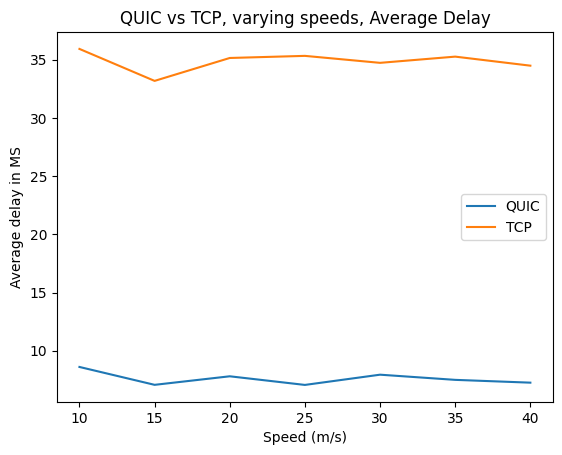

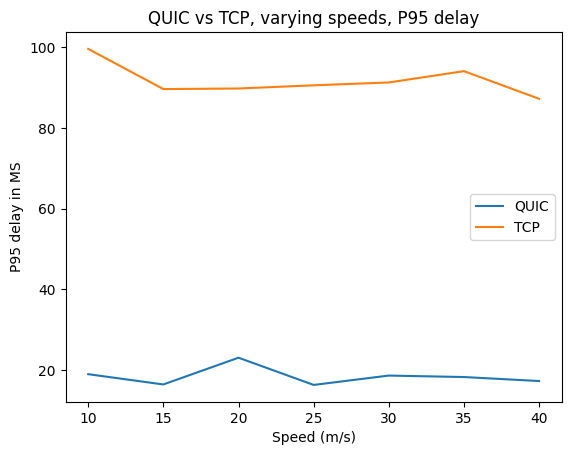

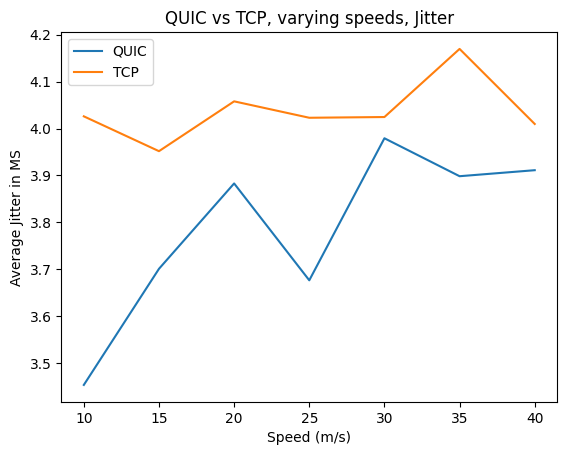

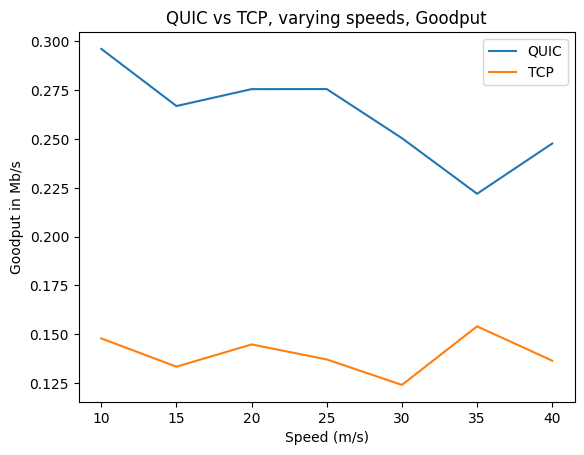

In [799]:
print("Speed Experiment")
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying speeds, Average Delay","Speed (m/s)","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying speeds, P95 delay","Speed (m/s)","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying speeds, Jitter","Speed (m/s)","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying speeds, Goodput","Speed (m/s)","Goodput in Mb/s")






Actual values

In [800]:
print("Averages, QUIC VS TCP")
print("QUIC:",AvgDelayArrayQUIC[0:,1])
print("TCP:",AvgDelayArrayTCP[0:,1])
print("P95, QUIC VS TCP")
print("QUIC: ",P95ArrayQUIC[0:,1])
print("TCP: ",P95ArrayTCP[0:,1])

print("MAX")
print("QUIC",np.max(GoodputArrayQUIC[0:,1]))
print("TCP",np.max(GoodputArrayTCP[0:,1]))
print("MIN")
print("QUIC",np.min(GoodputArrayQUIC[0:,1]))
print("TCP",np.min(GoodputArrayTCP[0:,1]))

Averages, QUIC VS TCP
QUIC: [8.6114386 7.075576  7.8093692 7.068299  7.9472556 7.5030112 7.262693 ]
TCP: [35.926992 33.18138  35.149022 35.33031  34.731256 35.265068 34.488344]
P95, QUIC VS TCP
QUIC:  [18.982474  16.4339428 23.0638162 16.3183626 18.6363    18.271148
 17.2811502]
TCP:  [99.591252 89.636146 89.7856   90.57003  91.27854  94.082736 87.22654 ]
MAX
QUIC 0.29616734
TCP 0.15400995
MIN
QUIC 0.22194323599999996
TCP 0.12398574000000001


Median results

Median results


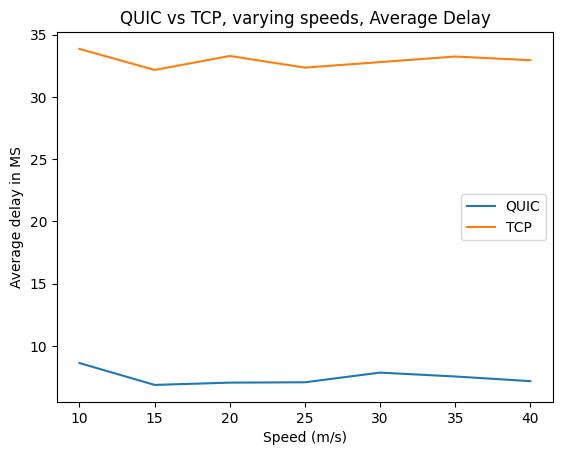

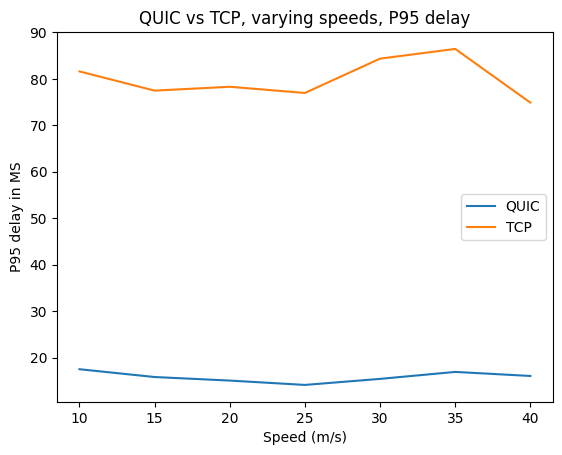

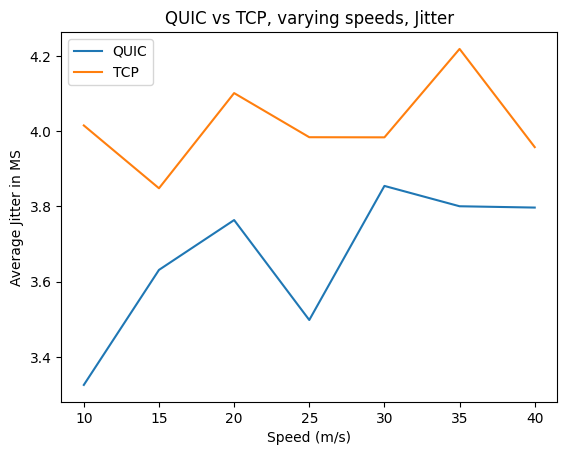

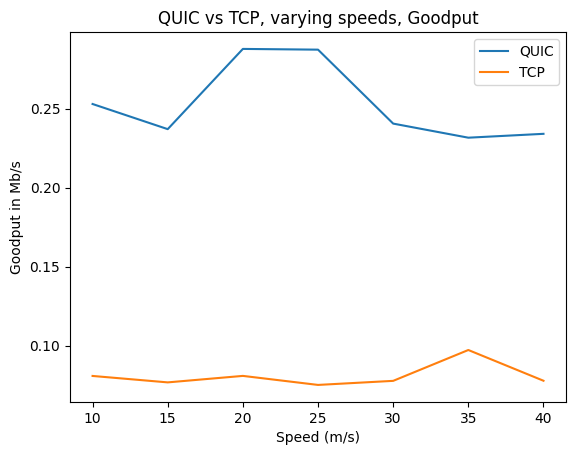

In [801]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying speeds, Average Delay","Speed (m/s)","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying speeds, P95 delay","Speed (m/s)","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying speeds, Jitter","Speed (m/s)","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying speeds, Goodput","Speed (m/s)","Goodput in Mb/s")

Boxplots

Boxplot


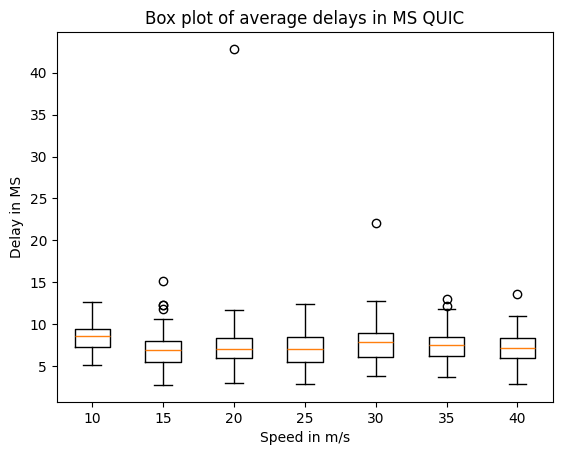

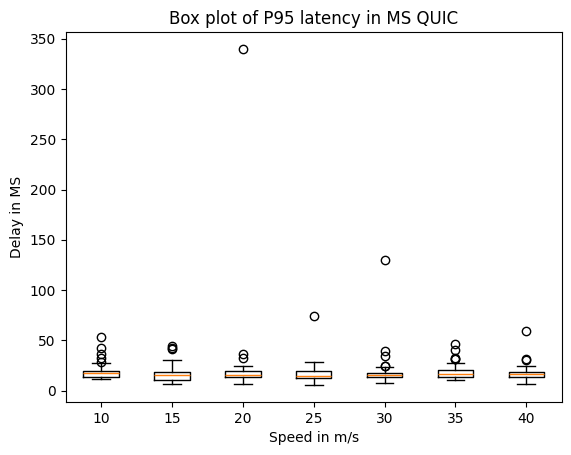

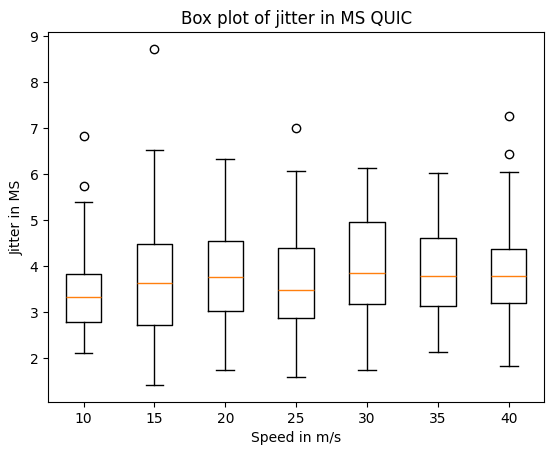

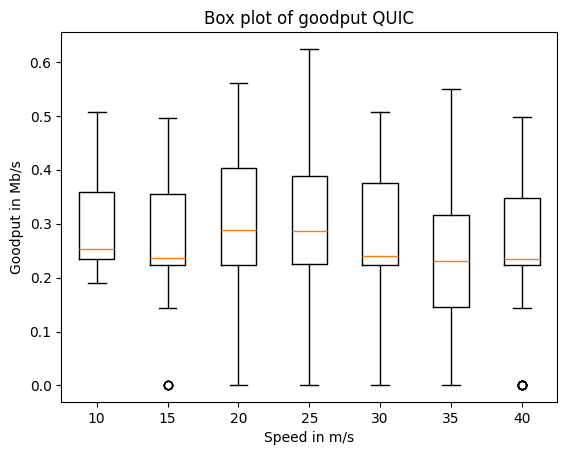

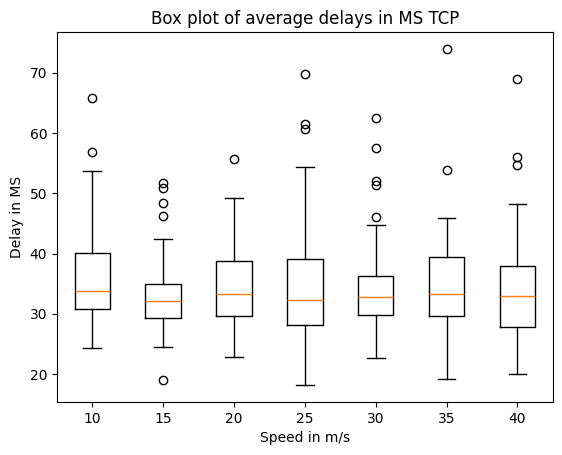

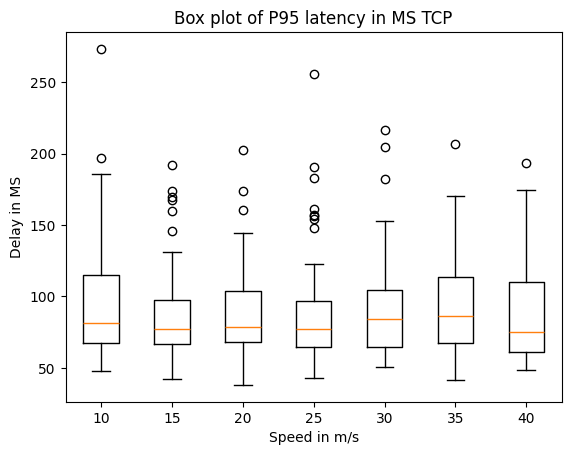

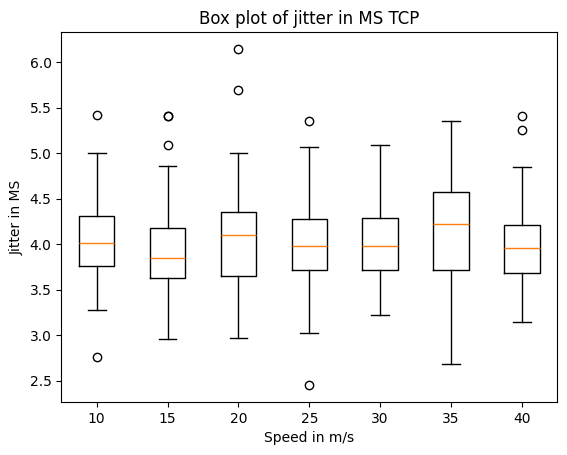

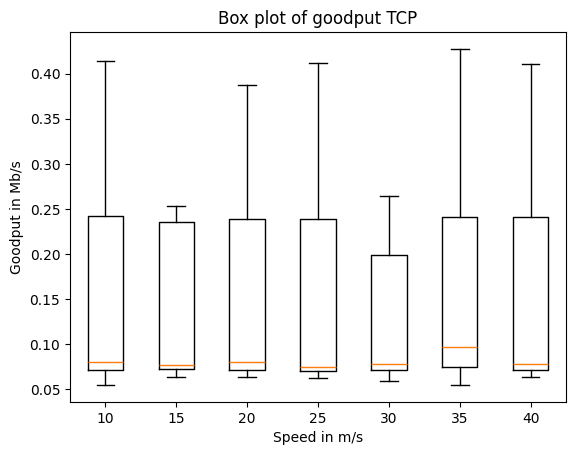

In [802]:
#BoxPlot
QUICCategories = QUICResults[0:,0:,3:7]
TCPCategories = TCPResults[0:,0:,3:7]
ticklabelsSpeed=["10","15","20","25","30","35","40"]
print("Boxplot")
####Box plots has a IQR value of 1.5 this is very popular according to wikipedia
#Plot QUIC
for i in range(0,len(MetricStringsYLabel)):
    PlotBoxplot(QUICCategories[0:,0:,i],MetricStringsTitles[i]+"QUIC","Speed in m/s",MetricStringsYLabel[i],ticklabelsSpeed)
#Plot TCP
for i in range(0,len(MetricStringsYLabel)):
    PlotBoxplot(TCPCategories[0:,0:,i],MetricStringsTitles[i]+"TCP","Speed in m/s",MetricStringsYLabel[i],ticklabelsSpeed)

Code for getting analytics about MAC retries.  

In [803]:
QUICMAC="QUICMACRETRYS/"
TCPMAC="TCPMACRETRYS/"

QUICPCAPCSVFiles = os.listdir("QUICMACRETRYS/")
TCPPCAPCSVFiles = os.listdir("TCPMACRETRYS/")
QUICPCAPCSVFiles.sort()
TCPPCAPCSVFiles.sort()


QUICSpeedFiles=[]
QUICVehicleFiles=[]
QUICPERFiles=[]

TCPSpeedFiles=[]
TCPVehicleFiles=[]
TCPPERFiles=[]
for i in QUICPCAPCSVFiles:
    temp=i.split('_')
    if (temp[0]=="PERExperiment"):
        QUICPERFiles.append(i)
    elif(temp[0]=="SpeedExperiment"):
        QUICSpeedFiles.append(i)
    else:
        QUICVehicleFiles.append(i)
for i in TCPPCAPCSVFiles:
    temp=i.split('_')
    if (temp[0]=="PERExperiment"):
        TCPPERFiles.append(i)
    elif(temp[0]=="SpeedExperiment"):
        TCPSpeedFiles.append(i)
    else:
        TCPVehicleFiles.append(i)



print("QUIC Speed")
print(QUICSpeedFiles)
print("QUIC Vehicle")
print(QUICVehicleFiles)
print("QUIC PER")
print(QUICPERFiles)
print("TCP Speed")
print(TCPSpeedFiles)
print("TCP Vehicle")
print(TCPVehicleFiles)
print("TCP PER")
print(TCPPERFiles)

QUIC Speed
['SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_10.000000_Vehicles_6_QUIC_MACRETRIES.csv', 'SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_15.000000_Vehicles_6_QUIC_MACRETRIES.csv', 'SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_20.000000_Vehicles_6_QUIC_MACRETRIES.csv', 'SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_25.000000_Vehicles_6_QUIC_MACRETRIES.csv', 'SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_30.000000_Vehicles_6_QUIC_MACRETRIES.csv', 'SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_35.000000_Vehicles_6_QUIC_MACRETRIES.csv', 'SpeedExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_40.000000_Vehicles_6_QUIC_MACRETRIES.csv']
QUIC Vehicle
['VehicleExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_15.000000_Vehicles_10_QUIC_MACRETRIES.csv', 'VehicleExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_15.000000_Vehicles_12_QUIC_MACRETRIES.csv', 'VehicleExperiment_OutputPCAPS_Folder_PER_0.000000_SPEED_15.000000_Vehicles_2_QUIC_MAC

plotting code for mac retrys

In [804]:
def PlotMACRetrys(XArr,QUICarr,TCPArr,XLabel,YLabel,Title):
    plt.plot(XArr,QUICarr,label="QUIC")
    plt.plot(XArr,TCPArr,label="TCP")
    plt.legend()
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()

In [805]:
def GetStatsFromMACRetryFiles(QUICFiles,TCPFiles):
    global QUICMAC
    global TCPMAC
    index=0
    QUICAverageArr=np.zeros(shape=(len(QUICFiles)))
    TCPAverageArr=np.zeros(shape=(len(TCPFiles)))
    QUICMedianArr=np.zeros(shape=(len(QUICFiles)))
    TCPMedianArr=np.zeros(shape=(len(TCPFiles)))
    QUICMAXArr=np.zeros(shape=(len(QUICFiles)))
    TCPMAXArr=np.zeros(shape=(len(TCPFiles)))
    QUICMINArr=np.zeros(shape=(len(QUICFiles)))
    TCPMINArr=np.zeros(shape=(len(TCPFiles)))
    QUICSTDArr=np.zeros(shape=(len(QUICFiles)))
    TCPSTDArr=np.zeros(shape=(len(TCPFiles)))

    QUICDatasetPTs=[]
    TCPDatasetPTs=[]

    for i in QUICFiles:
        temp=np.loadtxt(QUICMAC+i,dtype=float).astype(int)
        QUICAverageArr[index]=np.average(temp).astype(int)
        QUICMedianArr[index]=np.median(temp).astype(int)
        QUICMAXArr[index]=np.max(temp).astype(int)
        QUICMINArr[index]=np.min(temp).astype(int)
        QUICSTDArr[index]=np.std(temp).astype(int)
        QUICDatasetPTs.append(temp)
        index=index+1
    index=0
    for i in TCPFiles:
        temp2=np.loadtxt(TCPMAC+i,dtype=float).astype(int)
        TCPAverageArr[index]=np.average(temp2).astype(int)
        TCPMedianArr[index]=np.median(temp2).astype(int)
        TCPMAXArr[index]=np.max(temp2).astype(int)
        TCPMINArr[index]=np.min(temp2).astype(int)
        TCPSTDArr[index]=np.std(temp2).astype(int)
        TCPDatasetPTs.append(temp2)

        index=index+1

    return QUICAverageArr, QUICMedianArr, QUICMAXArr, QUICMINArr, QUICSTDArr, QUICDatasetPTs, TCPAverageArr, TCPMedianArr, TCPMAXArr, TCPMINArr, TCPSTDArr, TCPDatasetPTs

Speed experiment
[5031. 4885. 4043. 4707. 6457. 3988. 3761.]
[ 230. 3257. 3412.  177.  319. 1566.  229.]
4707.0
319.0


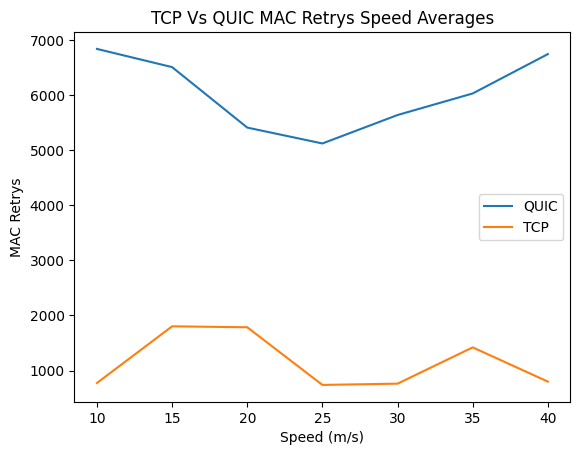

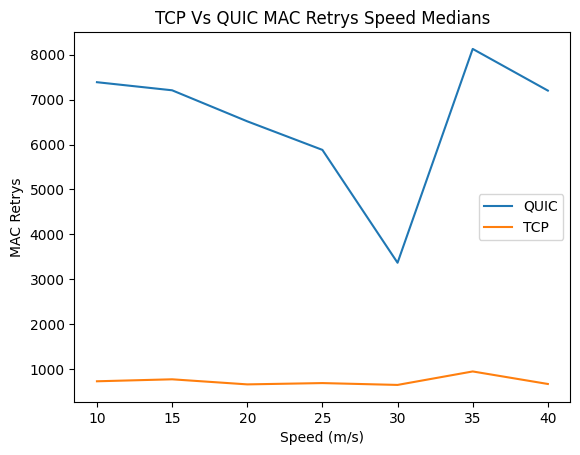

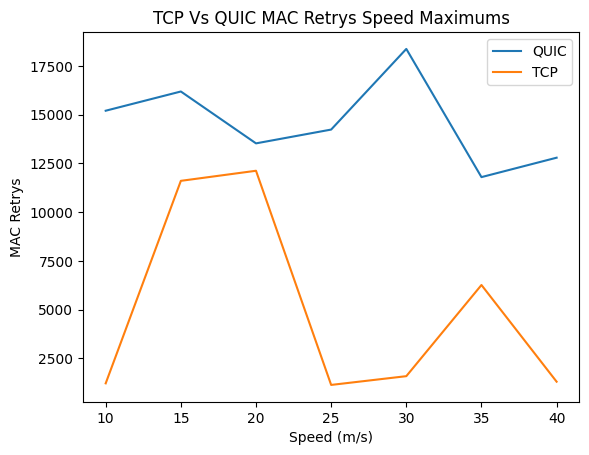

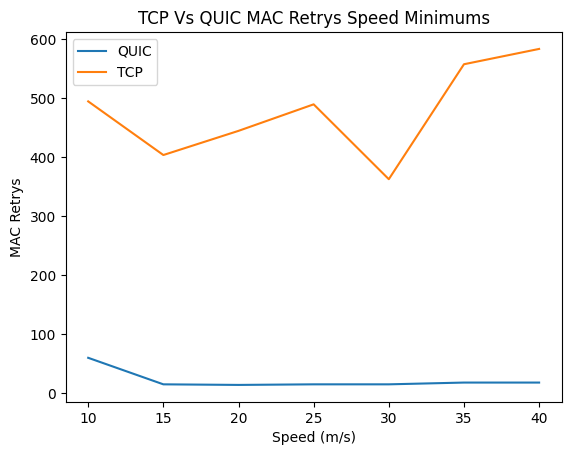

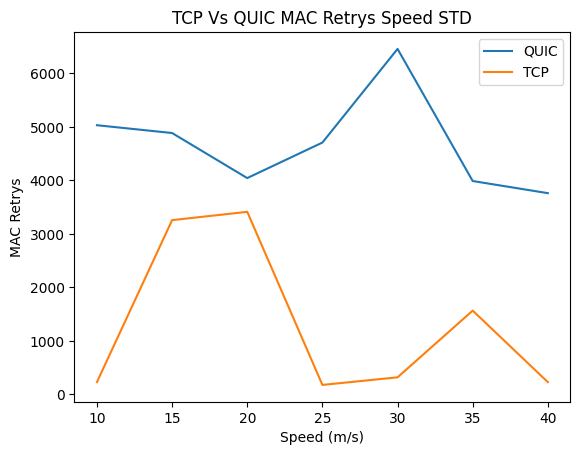

In [806]:
SpeedList=[10,15,20,25,30,35,40]

QUICAverageArr,QUICMedianArr,QUICMAXArr,QUICMINArr,QUICSTDArr,QUICDatasetPTs,TCPAverageArr,TCPMedianArr,TCPMAXArr,TCPMINArr,TCPSTDArr,TCPDatasetPTs=GetStatsFromMACRetryFiles(QUICSpeedFiles,TCPSpeedFiles)


print("Speed experiment")
print(QUICSTDArr)
print(TCPSTDArr)
print(np.median(QUICSTDArr))
print(np.median(TCPSTDArr))


PlotMACRetrys(SpeedList,QUICAverageArr,TCPAverageArr,"Speed (m/s)","MAC Retrys", "TCP Vs QUIC MAC Retrys Speed Averages")
PlotMACRetrys(SpeedList,QUICMedianArr,TCPMedianArr,"Speed (m/s)","MAC Retrys", "TCP Vs QUIC MAC Retrys Speed Medians")
PlotMACRetrys(SpeedList,QUICMAXArr,TCPMAXArr,"Speed (m/s)","MAC Retrys", "TCP Vs QUIC MAC Retrys Speed Maximums")
PlotMACRetrys(SpeedList,QUICMINArr,TCPMINArr,"Speed (m/s)","MAC Retrys", "TCP Vs QUIC MAC Retrys Speed Minimums")
PlotMACRetrys(SpeedList,QUICSTDArr,TCPSTDArr,"Speed (m/s)","MAC Retrys", "TCP Vs QUIC MAC Retrys Speed STD")





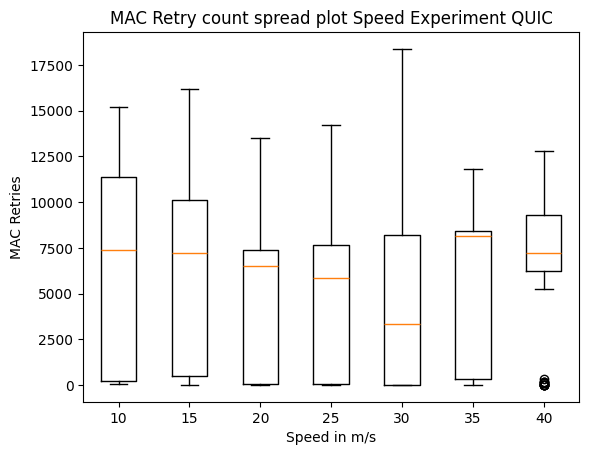

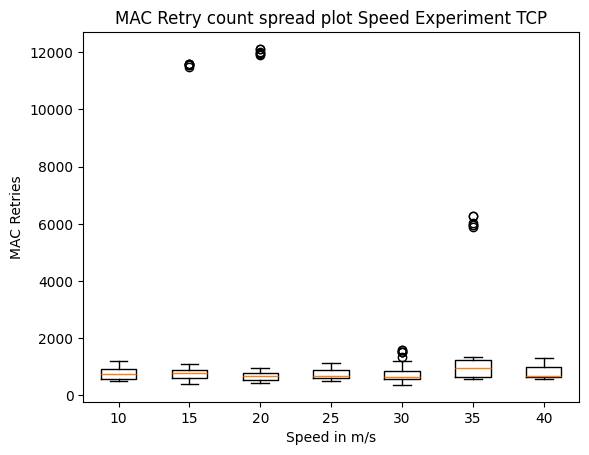

In [807]:
QUICpts = np.array(QUICDatasetPTs).transpose()
TCPpts = np.array(TCPDatasetPTs).transpose()


PlotBoxplot(QUICpts,"MAC Retry count spread plot Speed Experiment QUIC","Speed in m/s","MAC Retries",ticklabels=ticklabelsSpeed)
PlotBoxplot(TCPpts,"MAC Retry count spread plot Speed Experiment TCP","Speed in m/s","MAC Retries",ticklabels=ticklabelsSpeed)


Vehicle experiment
[ 979. 1824. 4016. 4615. 3790. 1903.]
[ 599. 1028.   73. 5898.  195.  627.]
2846.5
613.0


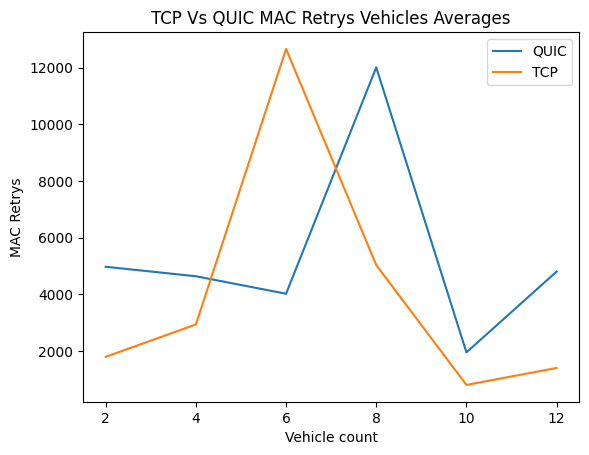

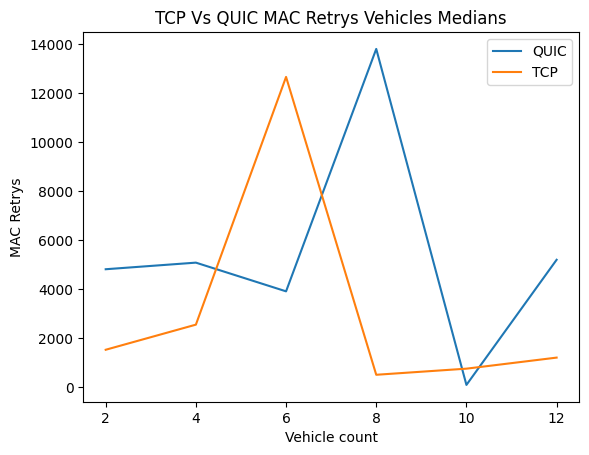

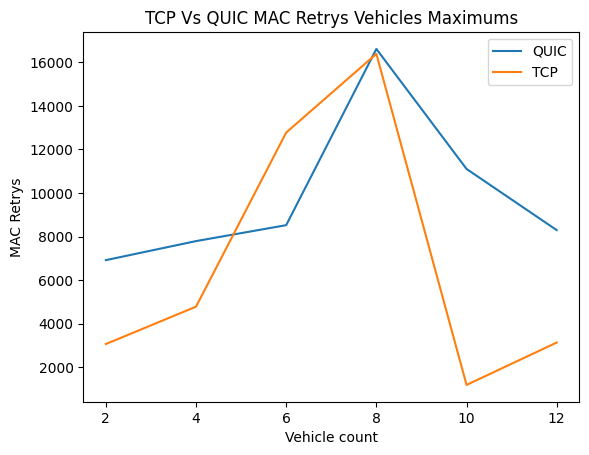

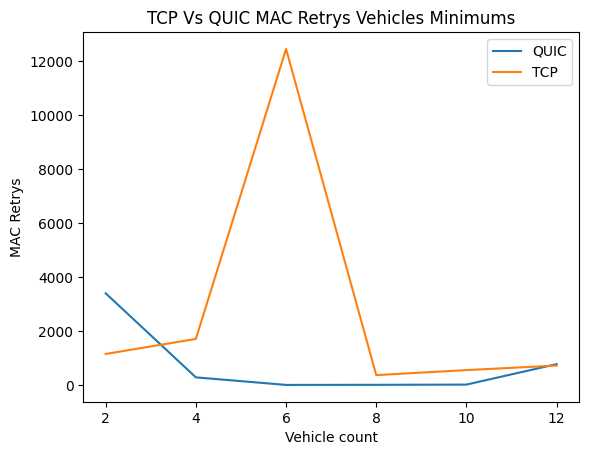

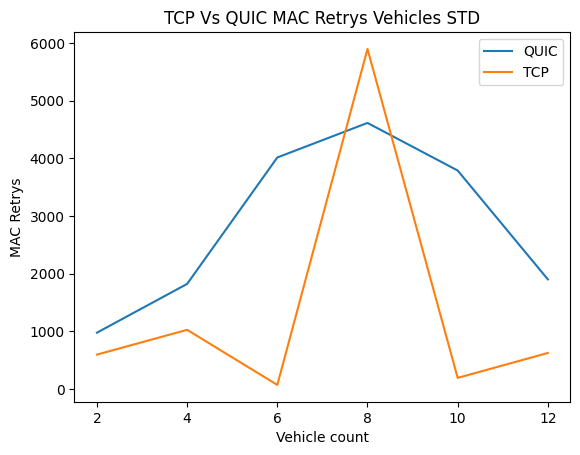

In [822]:
VehicleList=[2,4,6,8,10,12]

QUICAverageArr,QUICMedianArr,QUICMAXArr,QUICMINArr,QUICSTDArr,QUICDatasetPTs,TCPAverageArr,TCPMedianArr,TCPMAXArr,TCPMINArr,TCPSTDArr,TCPDatasetPTs=GetStatsFromMACRetryFiles(QUICVehicleFiles,TCPVehicleFiles)

print("Vehicle experiment")
print(QUICSTDArr)
print(TCPSTDArr)
print(np.median(QUICSTDArr))
print(np.median(TCPSTDArr))


PlotMACRetrys(VehicleList,QUICAverageArr,TCPAverageArr,"Vehicle count","MAC Retrys", "TCP Vs QUIC MAC Retrys Vehicles Averages")
PlotMACRetrys(VehicleList,QUICMedianArr,TCPMedianArr,"Vehicle count","MAC Retrys", "TCP Vs QUIC MAC Retrys Vehicles Medians")
PlotMACRetrys(VehicleList,QUICMAXArr,TCPMAXArr,"Vehicle count","MAC Retrys", "TCP Vs QUIC MAC Retrys Vehicles Maximums")
PlotMACRetrys(VehicleList,QUICMINArr,TCPMINArr,"Vehicle count","MAC Retrys", "TCP Vs QUIC MAC Retrys Vehicles Minimums")
PlotMACRetrys(VehicleList,QUICSTDArr,TCPSTDArr,"Vehicle count","MAC Retrys", "TCP Vs QUIC MAC Retrys Vehicles STD")

[5656 5343 4559 4729 6588 4673 5495 3861 5851 4623 4111 4253 3930 6879
 3635 5040 6877 4061 3806 4545 4101 5628 5970 3970 5162 6069 4570 4162
 4183 6231 5542 5944 3398 4740 4212 5990 5720 5192 5240 4242 3900 5432
 5532 5969 5300 4725 4195 6100 5844 4589 5329 5199 5848 3877 5699 3459
 3765 3887 5567 5704 3814 5372 4982 4190 4576 4065 6732 3959 4654 5633
 4181 3887 3509 5651 5462 5127 6851 4875 4741 5940 6918 5540 5836 6812
 6742 3752 3885 5353 5630 4485 3619 4722 3918 3644 4082 6735 3812 4150
 6913 3616]


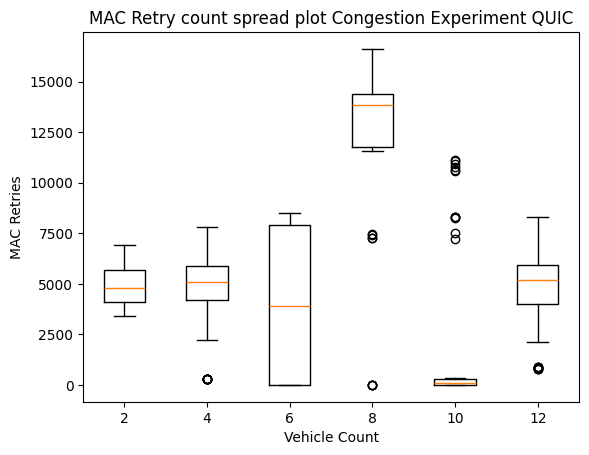

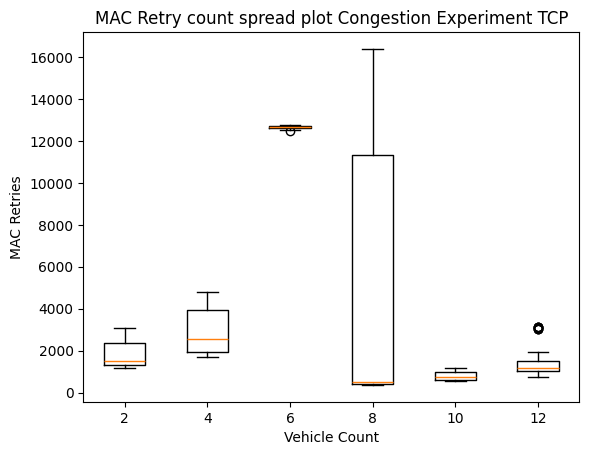

In [ ]:

PlotBoxplot(QUICDatasetPTs,"MAC Retry count spread plot Congestion Experiment QUIC","Vehicle Count","MAC Retries",ticklabels=ticklabelsVehicleCount)
PlotBoxplot(TCPDatasetPTs,"MAC Retry count spread plot Congestion Experiment TCP","Vehicle Count","MAC Retries",ticklabels=ticklabelsVehicleCount)

Vehicle experiment
[5285. 4333. 1557.  792.  800. 1926.]
[ 230.  925. 2461.  406.  685. 1228.]
1741.5
805.0


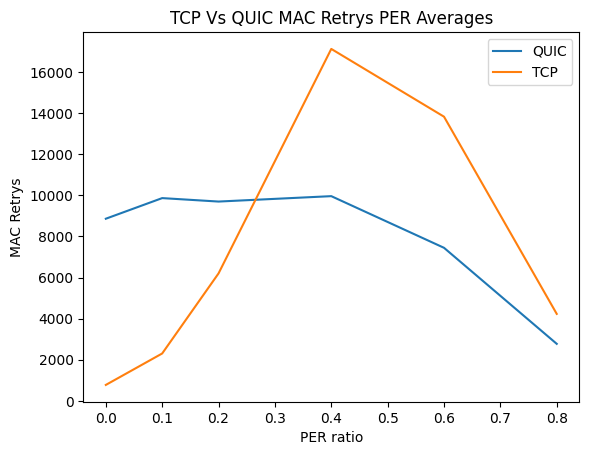

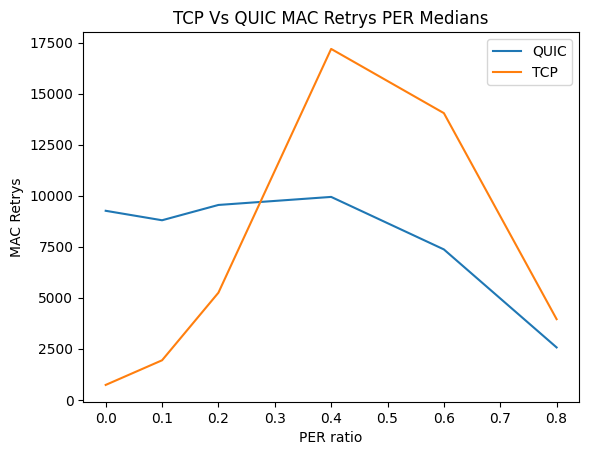

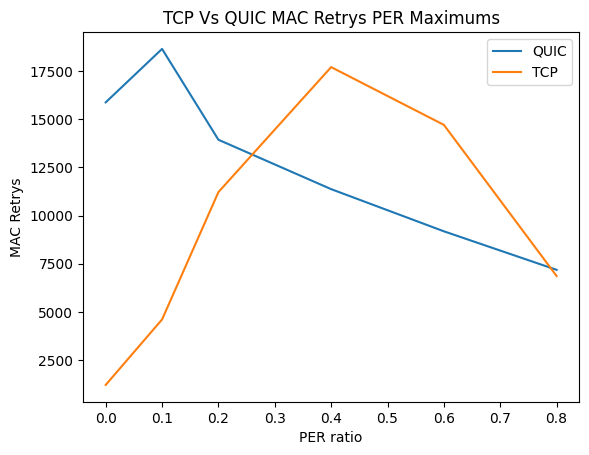

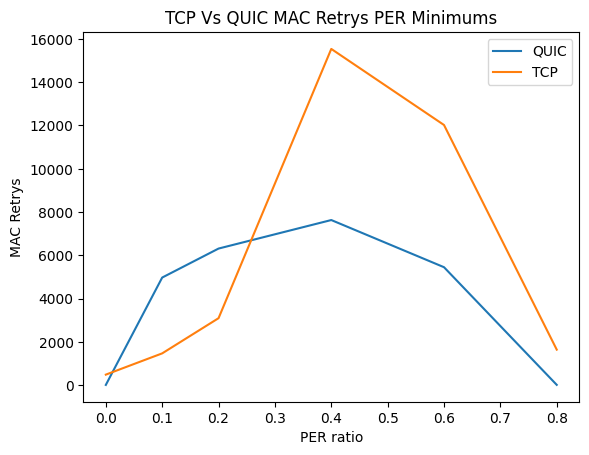

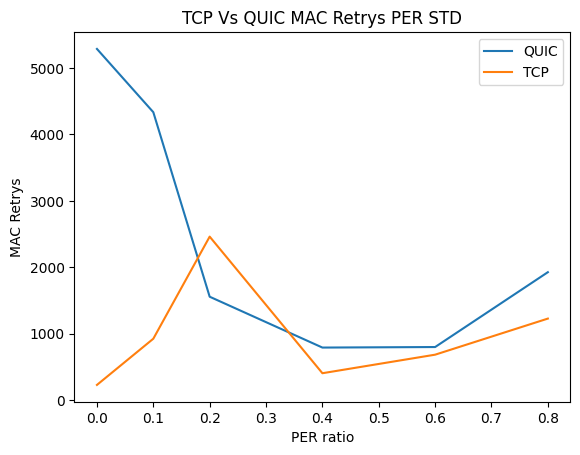

In [824]:
PERList=[0,0.1,0.2,0.4,0.6,0.8]

QUICAverageArr,QUICMedianArr,QUICMAXArr,QUICMINArr,QUICSTDArr,QUICDatasetPTs,TCPAverageArr,TCPMedianArr,TCPMAXArr,TCPMINArr,TCPSTDArr,TCPDatasetPTs=GetStatsFromMACRetryFiles(QUICPERFiles,TCPPERFiles)

print("Vehicle experiment")
print(QUICSTDArr)
print(TCPSTDArr)
print(np.median(QUICSTDArr))
print(np.median(TCPSTDArr))


PlotMACRetrys(PERList,QUICAverageArr,TCPAverageArr,"PER ratio","MAC Retrys", "TCP Vs QUIC MAC Retrys PER Averages")
PlotMACRetrys(PERList,QUICMedianArr,TCPMedianArr,"PER ratio","MAC Retrys", "TCP Vs QUIC MAC Retrys PER Medians")
PlotMACRetrys(PERList,QUICMAXArr,TCPMAXArr,"PER ratio","MAC Retrys", "TCP Vs QUIC MAC Retrys PER Maximums")
PlotMACRetrys(PERList,QUICMINArr,TCPMINArr,"PER ratio","MAC Retrys", "TCP Vs QUIC MAC Retrys PER Minimums")
PlotMACRetrys(PERList,QUICSTDArr,TCPSTDArr,"PER ratio","MAC Retrys", "TCP Vs QUIC MAC Retrys PER STD")

ValueError: Dimensions of labels and X must be compatible

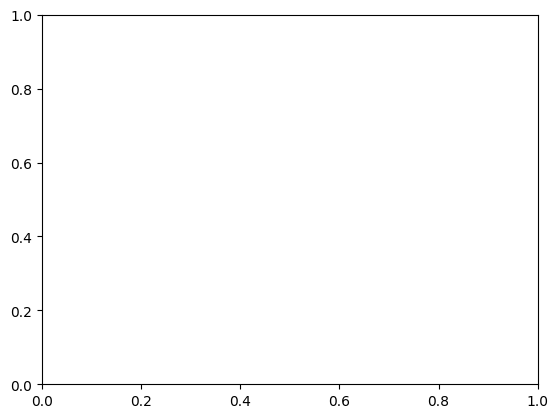

In [ ]:
QUICpts = np.array(QUICDatasetPTs).transpose()
TCPpts = np.array(TCPDatasetPTs).transpose()


PlotBoxplot(QUICpts,"MAC Retry count spread plot PER Experiment QUIC","PER","MAC Retries",ticklabels=ticklabelsPER)
PlotBoxplot(TCPpts,"MAC Retry count spread plot PER Experiment TCP","PER","MAC Retries",ticklabels=ticklabelsPER)